In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv('final preprocessed and cleaned data.csv')

In [3]:
df.head()

,Age,use_vegetables,num_meals_daily,CH2O,physical_activity,use_technological_devices,BMI,Gender_Male,family_history_with_overweight_yes,high_caloric_food_yes,...,smoking_yes,monitor_num_calories_yes,alcohol_Frequently,alcohol_Sometimes,alcohol_no,traveling_Bike,traveling_Motorbike,traveling_Public_Transportation,traveling_Walking,obesity_level
0,-0.458052,-0.787962,0.387607,-0.014691,-1.201111,0.517125,-0.652922,0,1,0,...,0,0,0,0,1,0,0,1,0,1
1,-0.458052,1.062931,0.387607,1.636239,2.324961,-1.127965,-0.671104,0,1,0,...,1,1,0,1,0,0,0,1,0,1
2,-0.008186,-0.787962,0.387607,-0.014691,1.149604,0.517125,-0.729071,1,1,0,...,0,0,1,0,0,0,0,1,0,1
3,0.788805,1.062931,0.387607,-0.014691,1.149604,-1.127965,-0.350662,1,0,0,...,0,0,1,0,0,0,0,0,1,5
4,-0.228227,-0.787962,-2.230910,-0.014691,-1.201111,-1.127965,-0.167916,1,0,0,...,0,0,0,1,0,0,0,1,0,6


In [4]:
x = df.drop(columns='obesity_level')
y = df['obesity_level']

In [5]:
x.head()

,Age,use_vegetables,num_meals_daily,CH2O,physical_activity,use_technological_devices,BMI,Gender_Male,family_history_with_overweight_yes,high_caloric_food_yes,...,food_bw_meals_no,smoking_yes,monitor_num_calories_yes,alcohol_Frequently,alcohol_Sometimes,alcohol_no,traveling_Bike,traveling_Motorbike,traveling_Public_Transportation,traveling_Walking
0,-0.458052,-0.787962,0.387607,-0.014691,-1.201111,0.517125,-0.652922,0,1,0,...,0,0,0,0,0,1,0,0,1,0
1,-0.458052,1.062931,0.387607,1.636239,2.324961,-1.127965,-0.671104,0,1,0,...,0,1,1,0,1,0,0,0,1,0
2,-0.008186,-0.787962,0.387607,-0.014691,1.149604,0.517125,-0.729071,1,1,0,...,0,0,0,1,0,0,0,0,1,0
3,0.788805,1.062931,0.387607,-0.014691,1.149604,-1.127965,-0.350662,1,0,0,...,0,0,0,1,0,0,0,0,0,1
4,-0.228227,-0.787962,-2.230910,-0.014691,-1.201111,-1.127965,-0.167916,1,0,0,...,0,0,0,0,1,0,0,0,1,0


In [6]:
y.head()

0    1
1    1
2    1
3    5
4    6
Name: obesity_level, dtype: int64

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [8]:
x_train

,Age,use_vegetables,num_meals_daily,CH2O,physical_activity,use_technological_devices,BMI,Gender_Male,family_history_with_overweight_yes,high_caloric_food_yes,...,food_bw_meals_no,smoking_yes,monitor_num_calories_yes,alcohol_Frequently,alcohol_Sometimes,alcohol_no,traveling_Bike,traveling_Motorbike,traveling_Public_Transportation,traveling_Walking
1378,-0.504513,-0.787962,-0.683864,0.522012,-0.153346,0.885067,0.421078,1,1,1,...,0,0,0,0,1,0,0,0,1,0
1826,-0.366885,1.062931,0.387607,-0.973657,0.798042,0.403430,1.756617,0,1,1,...,0,0,0,0,1,0,0,0,1,0
678,-0.936643,0.896990,0.387607,-1.665621,0.516092,-1.127965,-1.568967,0,0,0,...,0,0,1,0,1,0,0,0,1,0
1083,0.640479,0.663847,0.387607,0.258711,-0.195037,0.253350,-0.332017,0,1,1,...,0,0,0,1,0,0,0,0,0,0
1558,1.597993,0.740943,-0.435055,-1.665621,1.145475,-1.127965,0.800523,1,1,1,...,0,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,-1.216022,0.890913,0.387607,1.208398,0.232622,-1.066054,-0.185370,1,1,1,...,0,0,0,0,1,0,0,0,1,0
1294,0.011213,-1.678305,-2.230910,-0.014691,-1.201111,0.671839,0.239902,0,1,1,...,0,0,0,0,0,1,0,0,1,0
860,0.017242,-0.787962,0.387607,-0.014691,-0.807861,2.007290,-0.375401,1,1,1,...,0,0,0,0,1,0,0,0,1,0
1459,1.472408,0.385236,0.387607,-0.643192,0.970717,-0.429440,0.702218,1,1,1,...,0,0,0,0,1,0,0,0,1,0


In [9]:
y_test

889     5
1672    3
414     1
1599    3
849     5
       ..
909     5
261     1
576     0
963     6
240     5
Name: obesity_level, Length: 399, dtype: int64

In [10]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

In [11]:
y_pred = rf.predict(x_test)

In [12]:
accuracy_score(y_pred, y_test)*100

96.49122807017544

In [13]:
conf_matrix = confusion_matrix(y_test, y_pred)
pd.DataFrame(conf_matrix, columns=range(0,7))

,0,1,2,3,4,5,6
0,52,3,0,0,0,0,0
1,1,53,0,0,0,1,0
2,0,0,68,0,0,0,0
3,0,0,0,65,0,0,0
4,0,0,0,0,54,0,0
5,0,2,0,0,0,37,0
6,0,2,0,0,0,5,56


Text(0.5, 1.0, 'confusion_matrix')

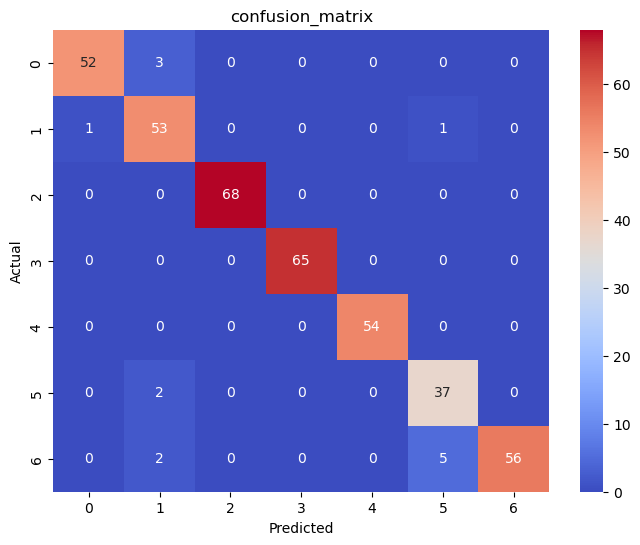

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("confusion_matrix")

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        55
           1       0.88      0.96      0.92        55
           2       1.00      1.00      1.00        68
           3       1.00      1.00      1.00        65
           4       1.00      1.00      1.00        54
           5       0.86      0.95      0.90        39
           6       1.00      0.89      0.94        63

    accuracy                           0.96       399
   macro avg       0.96      0.96      0.96       399
weighted avg       0.97      0.96      0.97       399



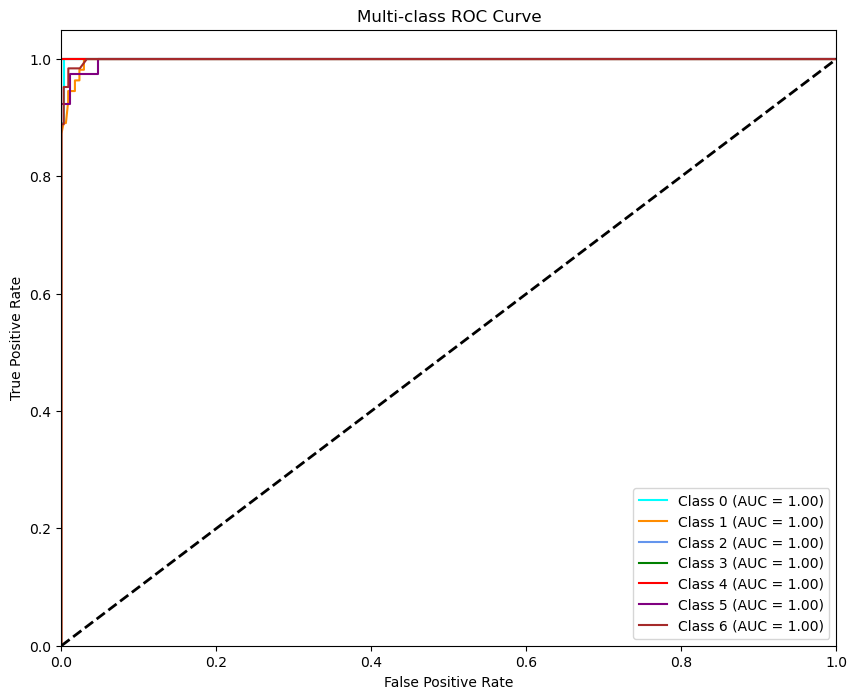

In [19]:
plt.figure(figsize=(10, 8))
for i in range(7):
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)],
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.show()